## Task 5 : Traffic Accident Data Analysis using Python

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

#### Load Dataset

In [2]:
df = pd.read_csv("US_Accidents_March23.csv", nrows=100000)

#### Basic Information

In [3]:
print(df.shape)
df.head()
df.info()
df.describe()

(100000, 46)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  str    
 1   Source                 100000 non-null  str    
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  str    
 4   End_Time               100000 non-null  str    
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  str    
 11  Street                 100000 non-null  str    
 12  City                   99999 non-null   str    
 13  County                 100000 non-null  str    
 14  State                  100000 non-n

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,100000.000000,100000.000000,100000.000000,0.0,0.0,100000.000000,98409.000000,4322.000000,98144.000000,98708.000000,98154.000000,76180.000000,7368.000000
mean,2.448120,35.630369,-119.322756,NaN,NaN,0.011345,66.641262,48.845812,59.794170,29.961021,9.338639,8.044165,0.025786
std,0.499931,2.101259,3.663525,NaN,NaN,0.262244,12.703846,19.898270,23.184442,0.275672,1.885828,4.298926,0.051695
min,1.000000,32.542587,-123.813927,NaN,NaN,0.000000,3.200000,-8.400000,4.000000,2.980000,0.100000,0.000000,0.000000
25%,2.000000,33.957775,-121.828468,NaN,NaN,0.000000,57.900000,37.100000,43.000000,29.890000,10.000000,4.600000,0.000000
50%,2.000000,34.168579,-118.384232,NaN,NaN,0.000000,66.000000,42.500000,62.000000,29.970000,10.000000,6.900000,0.000000
75%,3.000000,37.776682,-117.916023,NaN,NaN,0.010000,75.000000,63.000000,78.000000,30.060000,10.000000,10.400000,0.030000
max,4.000000,41.428753,-81.550728,NaN,NaN,51.130000,114.100000,107.000000,100.000000,33.040000,80.000000,241.700000,0.550000


#### Missing Values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

End_Lat                  100000
End_Lng                  100000
Wind_Chill(F)             95678
Precipitation(in)         92632
Wind_Speed(mph)           23820
Humidity(%)                1856
Visibility(mi)             1846
Weather_Condition          1604
Temperature(F)             1591
Pressure(in)               1292
Wind_Direction             1064
Weather_Timestamp          1054
Airport_Code                  7
Zipcode                       7
Timezone                      7
Sunrise_Sunset                1
Civil_Twilight                1
Nautical_Twilight             1
Astronomical_Twilight         1
City                          1
dtype: int64


#### Drop unnecessary columns

In [5]:
drop_cols = ['Wind_Chill(F)',
             'Precipitation(in)',
             'Turning_Loop']

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

#### Convert Date Column

In [6]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

#### Extract Time Features

In [7]:
df['Hour'] = df['Start_Time'].dt.hour
df['Month'] = df['Start_Time'].dt.month
df['Day'] = df['Start_Time'].dt.day_name()

#### Accident Distribution by Hour

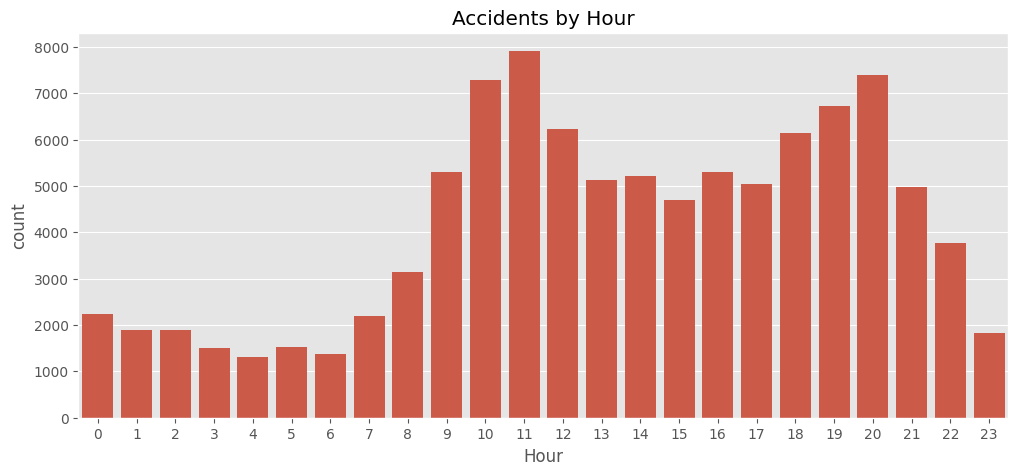

In [8]:
plt.figure(figsize=(12,5))
sns.countplot(x=df['Hour'])
plt.title("Accidents by Hour")
plt.show()

#### Accidents by Day

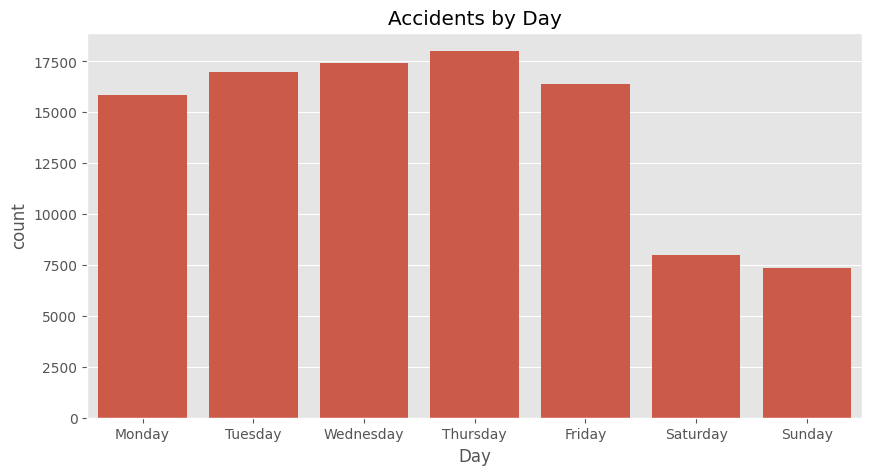

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='Day',
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.title("Accidents by Day")

plt.show()

#### Weather Condition Analysis

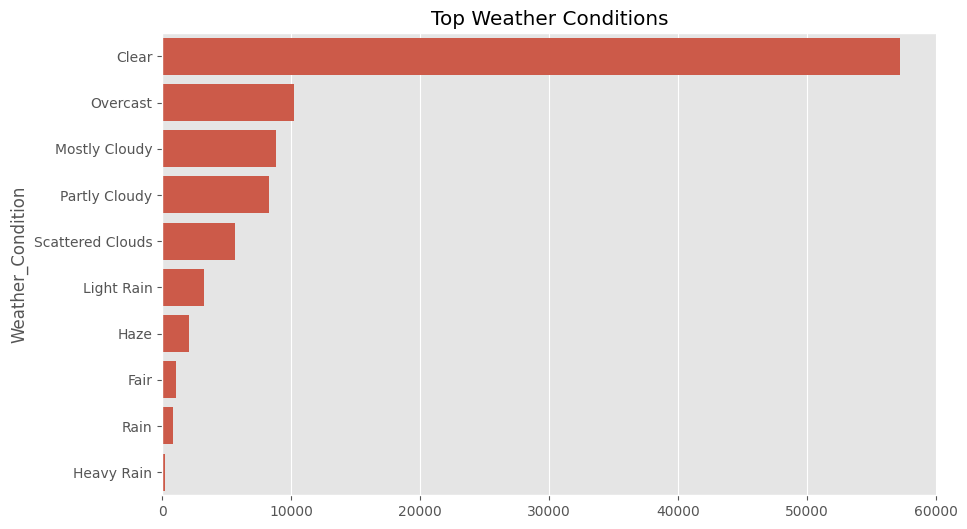

In [10]:
top_weather = df['Weather_Condition'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_weather.values,
    y=top_weather.index
)
plt.title("Top Weather Conditions")
plt.show()

#### Severity Distribution

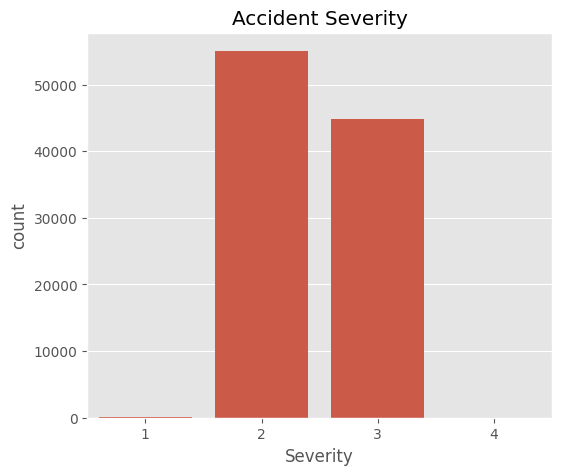

In [11]:
plt.figure(figsize=(6,5))
sns.countplot(x=df['Severity'])
plt.title("Accident Severity")
plt.show()

#### Road Condition Analysis

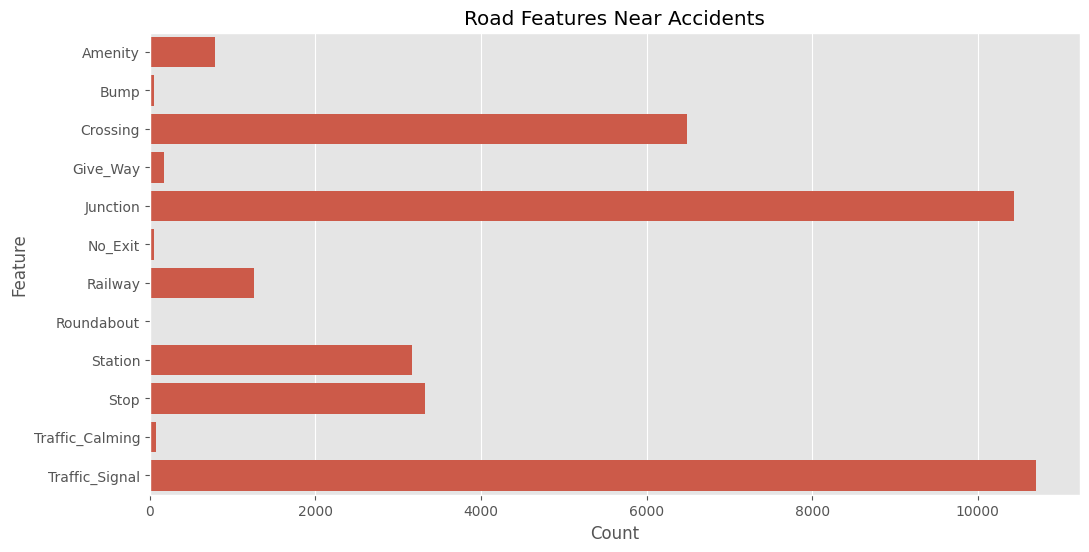

In [12]:
road_features = [
    'Amenity',
    'Bump',
    'Crossing',
    'Give_Way',
    'Junction',
    'No_Exit',
    'Railway',
    'Roundabout',
    'Station',
    'Stop',
    'Traffic_Calming',
    'Traffic_Signal'
]

counts = []

for feature in road_features:
    if feature in df.columns:
        counts.append(df[feature].sum())
    else:
        counts.append(0)

road_df = pd.DataFrame({
    "Feature": road_features,
    "Count": counts
})

plt.figure(figsize=(12,6))

sns.barplot(data=road_df, x='Count', y='Feature')

plt.title("Road Features Near Accidents")

plt.show()

#### Temperature vs Severity

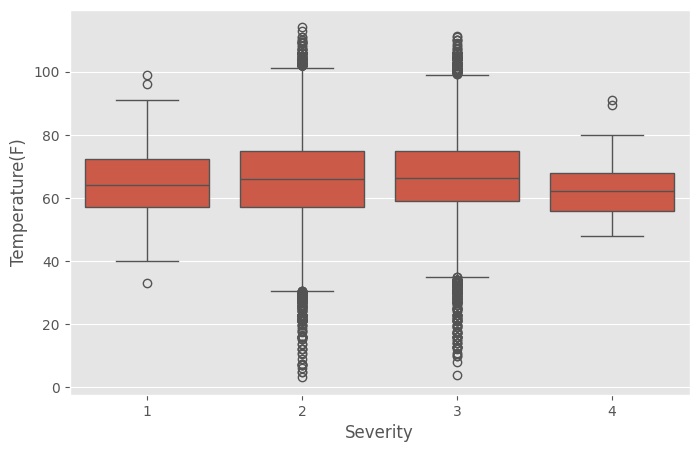

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Severity',
    y='Temperature(F)',
    data=df
)
plt.show()

#### Accident Hotspots

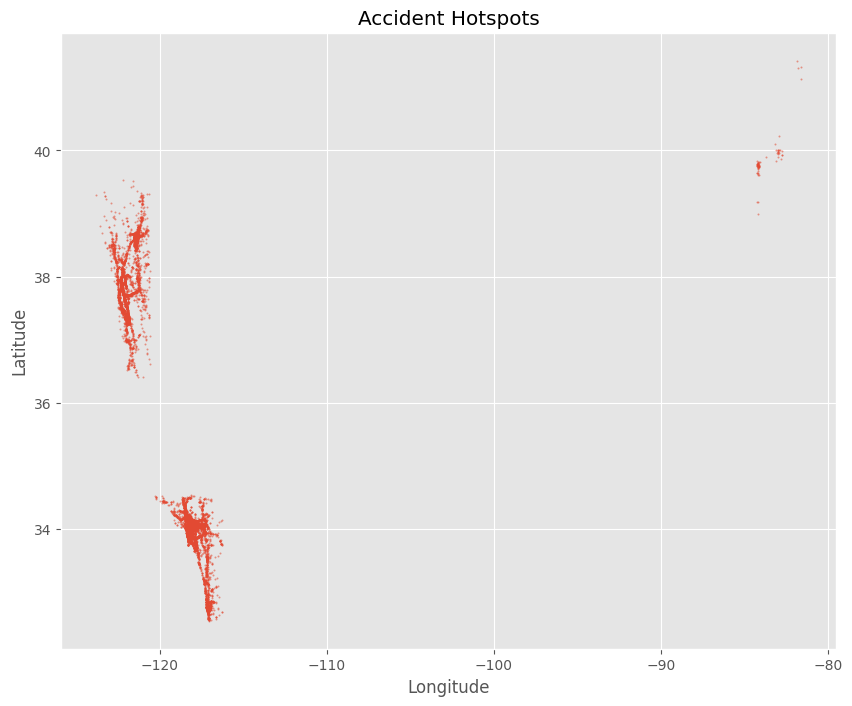

In [14]:
sample = df.sample(10000)
plt.figure(figsize=(10,8))
plt.scatter(
    sample['Start_Lng'],
    sample['Start_Lat'],
    s=1,
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident Hotspots")
plt.show()

#### Top States

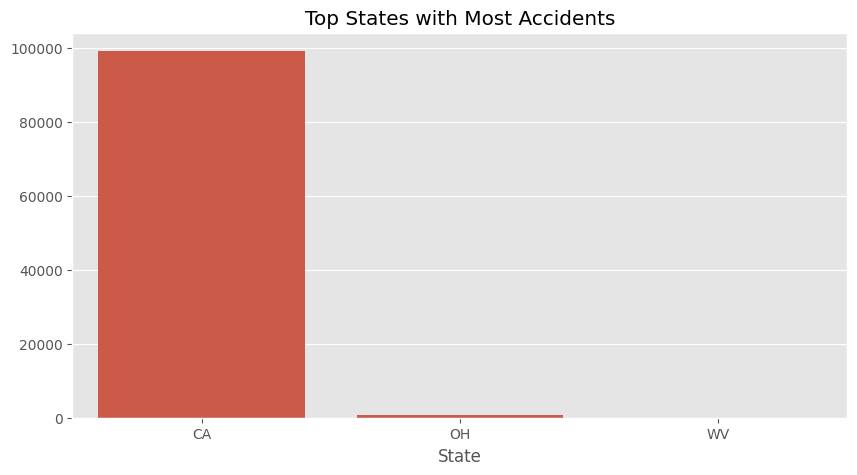

In [15]:
top_states = df['State'].value_counts().head(10)
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.title("Top States with Most Accidents")
plt.show()

#### Correlation Heatmap

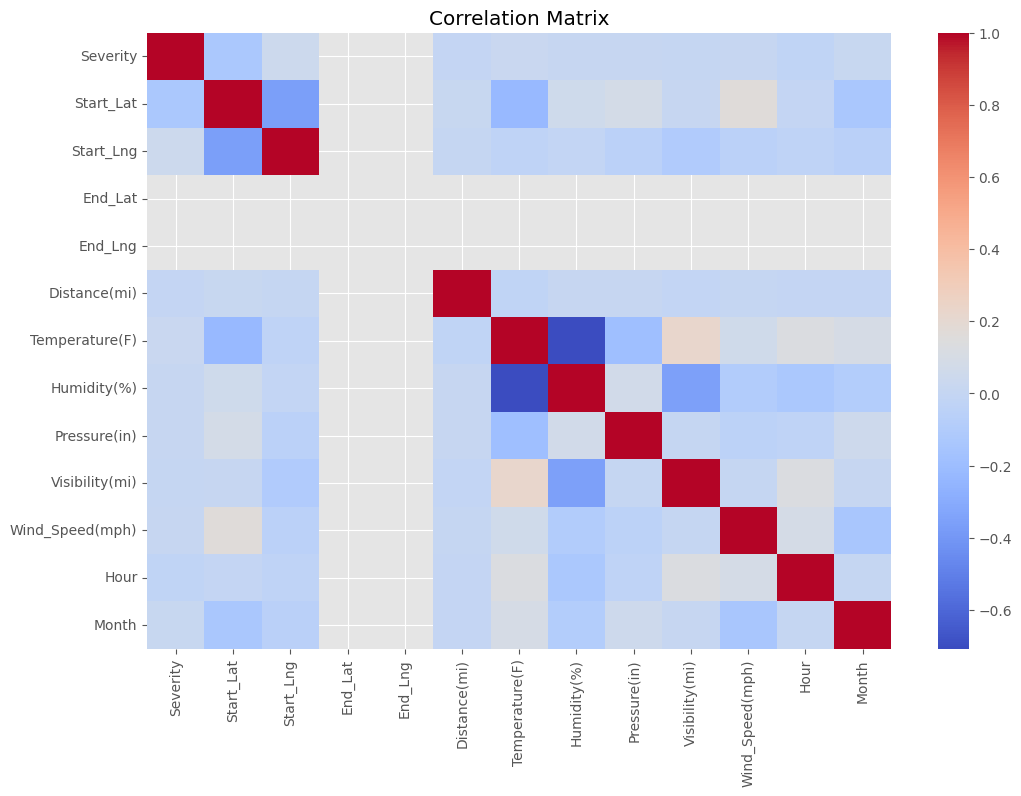

In [16]:
numeric = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(
    numeric.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()